In [14]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import gensim
from gensim.models import KeyedVectors
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import spacy



In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [16]:

word2vec_path = 'GoogleNews-vectors-negative300.bin'
word2vec = gensim.models.KeyedVectors.load_word2vec_format(word2vec_path, binary=True)

print(word2vec['hello'][:10])

[-0.05419922  0.01708984 -0.00527954  0.33203125 -0.25       -0.01397705
 -0.15039062 -0.265625    0.01647949  0.3828125 ]


In [20]:
nlp = spacy.load('en_core_web_sm')
stop_words = ['i', 'the', 'and', 'it', 'to', 'a', 'my', 'this', 'for', 'of', 'in', 'is', 'with', 'have', 'on', 'that', 'was', 'you', 'as', 'but', 'so', "'s",  'one', 'had', 'or', 'can', 'all', 'be', 'do', 'from', 'at', 'just', 'very', 'would', 'are', 'has', 'if', 'will', 'about', 'well', 'any', 'they', 'more', 'what', 'me', 'these', 'when']

def preprocess_text(text):

    if not isinstance(text,str):
        return text
    
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if not token.is_punct and token.text not in stop_words and token.lemma_ != '-PRON-'
    ]
    return ' '.join(tokens)

# sent = 'Hello i am The helper of someone'
# preprocess_text(sent)

In [21]:

# Define a custom dataset
class ReviewDataset(Dataset):
    def __init__(self, texts, ratings, max_len, embedding_model):
        self.texts = [preprocess_text(text) for text in texts]
        self.ratings = ratings
        self.max_len = max_len
        self.embedding_model = embedding_model
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        rating = self.ratings[idx]
        if isinstance(text,str):
            words = text.split()
            words = words[:self.max_len] + ['<PAD>'] * (self.max_len - len(words))
        else:
            words = ['<PAD>'] * (self.max_len)
        embedding = np.array([self.embedding_model[word] if word in self.embedding_model else np.zeros(300) for word in words])
        return torch.tensor(embedding, dtype=torch.float32), torch.tensor(rating, dtype=torch.long)



((3999, 2), (802, 2))

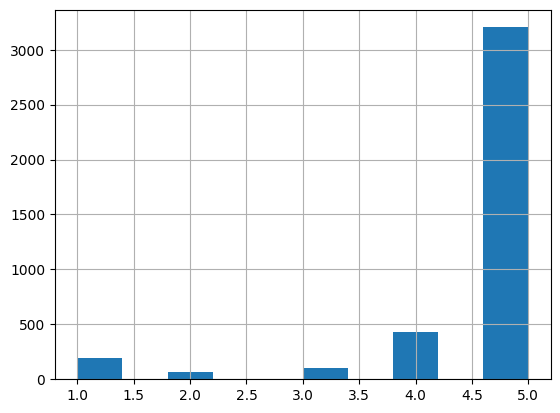

In [25]:


df_train = pd.read_excel('Aug24-Assignmen1-Dataset1.xlsx')
df_validate = pd.read_excel('Aug24-Assignment1-Validation-Dataset1.xlsx')

train_texts, val_texts = df_train['reviewText'].values, df_validate['reviewText'].values
train_ratings , val_ratings = df_train['overall'].values, df_validate['overall'].values



df_train['overall'].hist()
df_train.shape, df_validate.shape


In [26]:

label_encoder = LabelEncoder()
train_ratings = label_encoder.fit_transform(train_ratings)
val_ratings = label_encoder.transform(val_ratings)

max_len = 300
train_dataset = ReviewDataset(train_texts, train_ratings, max_len, word2vec)
val_dataset = ReviewDataset(val_texts, val_ratings, max_len, word2vec)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [27]:

class BiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, n_layers):
        super(BiLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=n_layers, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.softmax = nn.Softmax(dim=1)
    
    def forward(self, x):
        h_lstm, _ = self.lstm(x)
        h_lstm = h_lstm[:, -1, :]  
        out = self.fc(h_lstm)
        return self.softmax(out)

In [28]:

input_dim = 300
hidden_dim = 128
output_dim = len(label_encoder.classes_)
n_layers = 1

model = BiLSTM(input_dim, hidden_dim, output_dim, n_layers).to(device)

class_weights = compute_class_weight('balanced', classes=np.array([0, 1, 2, 3, 4]), y= train_ratings)
class_weights = torch.tensor(class_weights, dtype=torch.float)

print(class_weights)


criterion = nn.CrossEntropyLoss(class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.0001)


tensor([ 4.1227, 12.9000,  7.5453,  1.8471,  0.2496])


In [32]:

n_epochs = 10
for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    for embeddings, labels in tqdm(train_loader):
        #print(embeddings, labels)
        embeddings, labels = embeddings.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(embeddings).to(device)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{n_epochs}, Training Loss: {running_loss/len(train_loader)}")

    # Validation loop
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    actual_ratings = []
    predicted_ratings = []
    with torch.no_grad():
        for embeddings, labels in val_loader:
            embeddings, labels = embeddings.to(device), labels.to(device)
            outputs = model(embeddings).to(device)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            print(predicted)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            actual_ratings.extend(labels.cpu().numpy())
            predicted_ratings.extend(predicted.cpu().numpy())
    
    print(f"Validation Loss: {val_loss/len(val_loader)}, Accuracy: {100 * correct / total}%")



100%|██████████| 125/125 [01:27<00:00,  1.43it/s]


Epoch 1/10, Training Loss: 1.5977180557250976
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 

100%|██████████| 125/125 [01:32<00:00,  1.35it/s]


Epoch 2/10, Training Loss: 1.6001057214736938
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 

100%|██████████| 125/125 [01:26<00:00,  1.45it/s]


...

Epoch 8/10, Training Loss: 1.601786973953247
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4

100%|██████████| 125/125 [01:21<00:00,  1.54it/s]


Epoch 9/10, Training Loss: 1.6011239471435548
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 

100%|██████████| 125/125 [01:33<00:00,  1.34it/s]


Epoch 10/10, Training Loss: 1.6003235969543457
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,

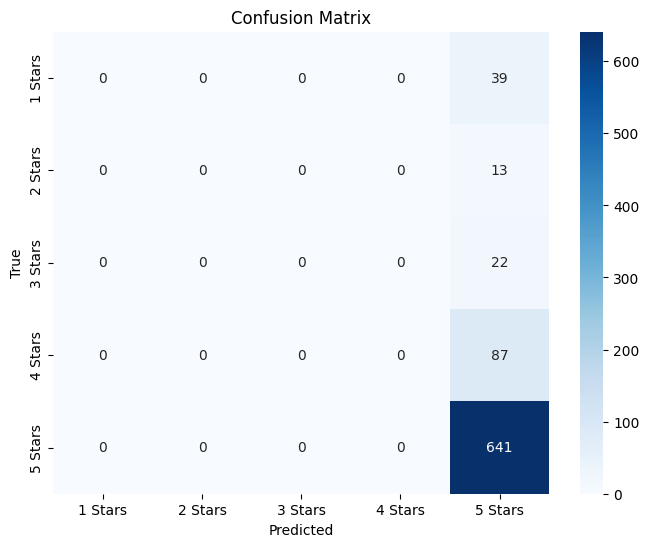

In [35]:
# print(actual_ratings)
# print(predicted_ratings)

cm = confusion_matrix(actual_ratings, predicted_ratings)

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[f"{i+1} Stars" for i in range(5)],
            yticklabels=[f"{i+1} Stars" for i in range(5)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [34]:
from sklearn.metrics import f1_score
report = classification_report(actual_ratings, predicted_ratings, target_names=[str(i + 1) + " Stars" for i in range(5)])
print(report)
print(f"{f1_score(actual_ratings, predicted_ratings, average='micro')}")


              precision    recall  f1-score   support

     1 Stars       0.00      0.00      0.00        39
     2 Stars       0.00      0.00      0.00        13
     3 Stars       0.00      0.00      0.00        22
     4 Stars       0.00      0.00      0.00        87
     5 Stars       0.80      1.00      0.89       641

    accuracy                           0.80       802
   macro avg       0.16      0.20      0.18       802
weighted avg       0.64      0.80      0.71       802

0.7992518703241895


/raid/home/asadali/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/raid/home/asadali/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/raid/home/asadali/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

In [ ]:

torch.save(model.state_dict(), 'bilstm_model.pth')